# Librerias

In [1]:
# coding: utf-8
from struct import unpack,pack
import numpy as np
import re
import pandas as pd
import os,sys,shutil
from datetime import datetime, timedelta, date
from urllib.request import urlretrieve
from scipy.interpolate import griddata
import argparse
import configparser
import pyproj
from scipy import spatial
import matplotlib.pyplot as plt

## Para  descargar ERA5 (incluir el api del cdsapi en .cdsapirc)
import cdsapi
import xarray as xr
import pandas as pd

# Configuracion de Archivos

### Fechas

Usar la fecha del Arhchivo

In [21]:
UsaFechaSlf = True

Fecha definida por usuario:

In [22]:
fecha = '21-08-2024'

### Rutas y Nombres de Archivos

In [23]:
rutabase = '/home/model2/Desktop/Telemac_varios/maga/carrera/tides/base/'
rutares = '/home/model2/Desktop/Telemac_varios/maga'
archivo_cli = 'bordeS.cli'
mallaCli = 'fondo.slf'
Resultados = 'r2d_m2wave.slf'
salida ='bordeC.csv'

### Harmónicos

Usa Harmónicos por Default

In [24]:
HarmDef = True

Harmónicos definidos por usuario:

In [25]:
const_default= ['M2', 'K1', 'O1', 'N2', 'S2', 'MSF', 'NO1', 'Q1','M4','M6', 'L2', 'S4']

## Conf Interna de Archivos

In [26]:
# identifica el borde
archC = os.path.join(rutabase,archivo_cli)
archS = os.path.join(rutabase,mallaCli)
archR = os.path.join(rutares,Resultados)
test = np.loadtxt(archC)

# Clases de Telemac


In [27]:
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Funciones globales
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

#lat lon to UTM
# UTM to lat lon
utm_zone = 19
southValue = True
P = pyproj.Proj(proj='utm', zone= utm_zone, south=southValue , ellps= 'WGS84', preserve_units =True)
G = pyproj.Geod(ellps='WGS84')

def utm_to_wgs84(easting, northing, utm_zone):
    #utm_crs = f"+proj=utm +zone={utm_zone} +ellps=WGS84 +datum=WGS84 +units=m +no_defs"
    #wgs84_crs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"
    #utm_projection = pyproj.Proj(utm_crs, preserve_units=True)
    #gs84_projection = pyproj.Proj(wgs84_crs)
    #lon, lat = pyproj.transform(utm_projection, wgs84_projection, easting, northing)
    return P(easting, northing, inverse=True)

def wgs84_to_utm(lon, lat):
    #utm_zone = (int((lon + 180) / 6) % 60) + 1
    #utm_crs = f"+proj=utm +zone={utm_zone} +ellps=WGS84 +datum=WGS84 +units=m +no_defs"
    #wgs84_crs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"
    #utm_projection = pyproj.Proj(utm_crs, preserve_units=True)
    #wgs84_projection = pyproj.Proj(wgs84_crs)
    #easting, northing = pyproj.transform(wgs84_projection, utm_projection, lat, lon)
    return P(lon,lat)


#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Clases from pputils
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

class ppSELAFIN:

  # object's properties
  def __init__(self, slf_file):
    
    # determine which version of python the user is running
    if (sys.version_info > (3, 0)):
      self.version = 3
    elif (sys.version_info > (2, 7)):
      self.version = 2
    
    self.slf_file = slf_file

    self.endian = '>' # always assume big endian
    
    # For C float type use size 4
    # For C double type use size 8
    # defaults are single precision selafin
    # for double precision, use setPrecision, and change it to 'd', 8
    self.float_type = 'f' 
    self.float_size = 4
    
    self.title = ''
    self.precision = 'SELAFIN '
    self.NBV1 = 0
    self.NBV2 = 0
    
    # variables and units
    self.vars = []
    
    self.vnames = []
    self.vunits = []
    
    self.IPARAM = []
    
    self.NPLAN = 0 # number of vertical planes; =1 for 2d; >1 for 3d
    
    # Aug 29, 1997 2:15 am EST (date when skynet became self-aware)
    self.DATE = [1997, 8, 29, 2, 15, 0] 
    
    self.NELEM = 0
    self.NPOIN = 0
    self.NDP = 0
    
    self.IKLE = np.zeros((self.NELEM,self.NPOIN), dtype=np.int32)
    
    self.IPOBO = np.zeros(self.NPOIN, dtype=np.int32)
    
    self.x = np.zeros(self.NPOIN)
    self.y = np.zeros(self.NPOIN)
    
    self.time = []
    
    # temporary array that hold results read for a single time step
    # for each variable in the file
    self.temp = np.zeros((self.NBV1,self.NPOIN))
    
    self.tempAtNode = np.zeros((0,0))
    
  # methods start here
  def readHeader(self):
    self.f = open(self.slf_file, 'rb')
    garbage = unpack('>i', self.f.read(4))[0]
      
    if (self.version == 2):
      self.title = unpack('>72s', self.f.read(72))[0]
      self.precision = unpack('>8s', self.f.read(8))[0]
    else:
      self.title = unpack('>72s', self.f.read(72))[0].decode()
      self.precision = unpack('>8s', self.f.read(8))[0].decode()
    garbage = unpack('>i', self.f.read(4))[0]
    
    garbage = unpack('>i', self.f.read(4))[0]
    self.NBV1 = unpack('>i', self.f.read(4))[0] # variables
    self.NBV2 = unpack('>i', self.f.read(4))[0] # quad variables, not used
    garbage = unpack('>i', self.f.read(4))[0]
    
    # each item in the vars list has 32 characters; 16 for name, and 16 for unit
    for i in range(self.NBV1):
      garbage = unpack('>i', self.f.read(4))[0]
      if (self.version ==2):
        self.vars.append(unpack('>32s', self.f.read(32))[0])
      else:
        self.vars.append(unpack('>32s', self.f.read(32))[0].decode())
      garbage = unpack('>i', self.f.read(4))[0]  
      
    for i in range(self.NBV1):
      self.vnames.append(self.vars[i][0:15])
      self.vunits.append(self.vars[i][16:31])
    
    # added on 2016.07.06 
    # after reading the variable names, make sure they are padded with spaces!
    # Paraview legacy *.vtk reader doesn't like this junk after variable names!!!
    
    # make sure title and precision is padded
    self.title = '{:<72}'.format(self.title)
    self.precision = '{:<8}'.format(self.precision)
    
    # make sure that variable names and units are paded
    for i in range(self.NBV1):
      # sometimes sisyphe vnames and vunits would have this garbage
      # part of the strings, which have to be removed.
      self.vnames[i] = self.vnames[i].replace('\x00', '')  
      self.vunits[i] = self.vunits[i].replace('\x00', '')
      
      # pad it with spaces
      self.vnames[i] = '{:<16}'.format(self.vnames[i])
      self.vunits[i] = '{:<16}'.format(self.vunits[i])    
    
    garbage = unpack('>i', self.f.read(4))[0]
    self.IPARAM = unpack('>10i', self.f.read(10*4))
    garbage = unpack('>i', self.f.read(4))[0]
    
    if (self.IPARAM[-1] == 1):
      garbage = unpack('>i', self.f.read(4))[0]
      # date is 6 integers stored as a list
      self.DATE = unpack('>6i', self.f.read(6*4))
      garbage = unpack('>i', self.f.read(4))[0]
    
    if (self.IPARAM[6] > 1):
      # the *.slf file is 3d
      self.NPLAN = self.IPARAM[6]
    else:
      # the *.slf file is 2d (this is the default)
      self.NPLAN = 1
    
    # uses python's long instead of integer 
    garbage = unpack('>i', self.f.read(4))[0]
    self.NELEM = unpack('>l', self.f.read(4))[0]
    self.NPOIN = unpack('>l', self.f.read(4))[0]
    self.NDP = unpack('>i', self.f.read(4))[0]
    dummy = unpack('>i', self.f.read(4))[0]
    garbage = unpack('>i', self.f.read(4))[0]
    
    self.IKLE = np.zeros((self.NELEM, self.NDP), dtype=np.int32)
    
    garbage = unpack('>i', self.f.read(4))[0]
    for i in range(self.NELEM):
      for j in range(self.NDP):
        self.IKLE[i,j] = unpack('>l', self.f.read(4))[0]
    garbage = unpack('>i', self.f.read(4))[0]    
    
    self.IPOBO = np.zeros(self.NPOIN, dtype=np.int32)
    
    garbage = unpack('>i', self.f.read(4))[0]
    for i in range(self.NPOIN):
      self.IPOBO[i] = unpack('>l', self.f.read(4))[0]
    garbage = unpack('>i', self.f.read(4))[0]
      
    # reads x
    self.x = np.zeros(self.NPOIN)
    garbage = unpack('>i', self.f.read(4))[0]
    
    # this is where we decide if it is single of double precision
    # I got this from HRW's getFloatTypeFromFloat method
    # I would have never gotten this on my own!!!
    if (garbage != self.float_size * self.NPOIN):
      self.float_type = 'd'
      self.float_size = 8  
    
    for i in range(self.NPOIN):
      self.x[i] = unpack('>' + self.float_type, self.f.read(self.float_size))[0]
    garbage = unpack('>i', self.f.read(4))[0]
    
    # reads y 
    self.y = np.zeros(self.NPOIN)
    garbage = unpack('>i', self.f.read(4))[0]
    for i in range(self.NPOIN):
      self.y[i] = unpack('>' + self.float_type, self.f.read(self.float_size))[0]
    garbage = unpack('>i', self.f.read(4))[0]
    
  def writeHeader(self):
    self.f = open(self.slf_file, 'wb')
    
    # added on 2016.06.23 thanks to Yoann Audouin
    # before writing the variable names, make sure they are padded with spaces!
    
    # make sure title and precision is padded
    self.title = '{:<72}'.format(self.title)
    self.precision = '{:<8}'.format(self.precision)
    
    # make sure that variable names and units are paded
    for i in range(self.NBV1):
      self.vnames[i] = '{:<16}'.format(self.vnames[i])
      self.vunits[i] = '{:<16}'.format(self.vunits[i])
    
    # now we are ready to write the data
    self.f.write(pack('>i', 80))
    self.f.write(pack('>72s', self.title.encode()))
    self.f.write(pack('>8s', self.precision.encode()))
    self.f.write(pack('>i', 80))
    
    self.f.write(pack('>i', 8))
    self.f.write(pack('>i', self.NBV1))
    self.f.write(pack('>i', self.NBV2))
    self.f.write(pack('>i', 8))
    
    # writeHeader() must only be called after setVarUnits and setVarNames
    for i in range(self.NBV1):
      self.f.write(pack('>i',32))
      self.f.write(pack('>16s',self.vnames[i].encode()))
      self.f.write(pack('>16s',self.vunits[i].encode()))
      self.f.write(pack('>i',32))

    self.f.write(pack('>i', 40))
    for i in range(len(self.IPARAM)):
      self.f.write(pack('>i', self.IPARAM[i]))
    self.f.write(pack('>i', 40))
    
    if (self.IPARAM[-1] == 1):
      self.f.write(pack('>i', 24))
      # date is 6 integers stored as a list
      for i in range(len(self.DATE)):
        self.f.write(pack('>i', self.DATE[i]))
      self.f.write(pack('>i', 24))
      
    self.f.write(pack('>i', 16))
    self.f.write(pack('>i', self.NELEM))
    self.f.write(pack('>i', self.NPOIN))
    self.f.write(pack('>i', self.NDP))
    self.f.write(pack('>i', 1)) # NPLAN???
    self.f.write(pack('>i', 16))
    
    self.f.write(pack('>i', 4*self.NELEM*self.NDP))
    for i in range(self.NELEM):
      for j in range(self.NDP):
        self.f.write(pack('>i', self.IKLE[i,j]))
    self.f.write(pack('>i', 4*self.NELEM*self.NDP))
    
    self.f.write(pack('>i', 4*self.NPOIN))
    for i in range(len(self.IPOBO)):
      self.f.write(pack('>i', self.IPOBO[i]))
    self.f.write(pack('>i', 4*self.NPOIN))
    
    # this is the garbage record that determines the float size
    # I have no idea why this works, but it does!!!
    self.f.write(pack('>i', self.float_size*self.NPOIN))
    for i in range(len(self.x)):
      self.f.write(pack('>'+self.float_type, self.x[i]))
    self.f.write(pack('>i', self.float_size*self.NPOIN))

    self.f.write(pack('>i', self.float_size*self.NPOIN))
    for i in range(len(self.y)):
      self.f.write(pack('>'+self.float_type, self.y[i]))
    self.f.write(pack('>i', self.float_size*self.NPOIN))
    
  def writeVariables(self,time,temp):
    # appends object's time 
    self.time.append(time)
    
    # keeps only the current 2d array in object's memory
    self.temp = temp
    
    # write the time 
    self.f.write(pack('>i', 4))
    self.f.write(pack('>'+self.float_type, time))
    self.f.write(pack('>i', 4))
    
    # writes the rest of the variables
    for j in range(self.NBV1):
      self.f.write(pack('>i', self.float_size*self.NPOIN))
      for k in range(self.NPOIN):
        self.f.write(pack('>'+self.float_type, self.temp[j,k]))
      self.f.write(pack('>i', self.float_size*self.NPOIN))
    
  def readTimes(self):
    pos_prior_to_time_reading = self.f.tell()
    
    while True:
      try:
        # get the times
        self.f.seek(4,1)
        self.time.append( unpack('>'+self.float_type, self.f.read(self.float_size))[0] )
        self.f.seek(4,1)
        
        # skip through the variables
        self.f.seek(self.NBV1*(4+self.float_size*self.NPOIN+4), 1)
        
        # skip the variables
        # 4 at begining and end are garbage
        # 4*NPOIN assumes each times step there are NPOIN nodes of 
        # size 4 bytes (i.e., single precision)
        # f.seek(NBV1*(4+4*NPOIN+4), 1)
      except:
        break
    self.f.seek(pos_prior_to_time_reading)
    
  def readVariables(self,t_des):
    # print('Desired time: ' + str(t_des) + '\n')
    pos_prior_to_var_reading = self.f.tell()
    
    # reads data for all variables in the *.slf file at desired time t_des
    self.temp = np.zeros((self.NBV1,self.NPOIN))
    
    # it reads the time again, but this it is not used
    time2 = []
    
    # time index
    t = -1
    
    while True:
      try:
        self.f.seek(4,1)
        time2.append( unpack('>'+self.float_type, self.f.read(self.float_size))[0] )
        self.f.seek(4,1)
        
        t = t + 1
        
        if (t == t_des):
          # print('slf time: ' + str(t))
          for i in range(self.NBV1):
            self.f.seek(4,1)
            for j in range(self.NPOIN):
              self.temp[i,j] = unpack('>'+self.float_type, self.f.read(self.float_size))[0]
            self.f.seek(4,1)
        else:
          self.f.seek(self.NBV1*(4+self.float_size*self.NPOIN+4), 1)
      except:
        break
        
    # need to re-set in case another variable needs to be read!
    self.f.seek(pos_prior_to_var_reading)    

  def readVariablesAtNode(self,node):
    
    # node is the desired node from which to extract results for
    numTimes = len(self.time)
    
    pos_prior_to_var_reading = self.f.tell()
    
    # reads data for all variables in the *.slf file at desired time t_des
    self.tempAtNode = np.zeros((numTimes, self.NBV1))
    
    # it reads the time again, but this it is not used
    time2 = []
    
    # time index
    t = -1
    
    while True:
      try:
        self.f.seek(4,1)
        time2.append( unpack('>'+self.float_type, self.f.read(self.float_size))[0] )
        self.f.seek(4,1)
        
        # this is the time step index
        t = t + 1
        
        for i in range(self.NBV1):
          self.f.seek(4,1)
          
          self.f.seek( (node)*self.float_size, 1)
          self.tempAtNode[t,i] = unpack('>'+self.float_type, self.f.read(self.float_size))[0]
          self.f.seek ((self.NPOIN - node -1)*self.float_size , 1)
              
          self.f.seek(4,1)
      except:
        break
        
    # need to re-set in case another variable needs to be read!
    self.f.seek(pos_prior_to_var_reading)  
    
  # get methods start here
  def getPrecision(self):
    return self.float_type,self.float_size
    
  def getNPOIN(self):
    return self.NPOIN

  def getNELEM(self):
    return self.NELEM
      
  def getTimes(self):
    return self.time
    
  def getVarNames(self):
    return self.vnames
    
  def getVarUnits(self):
    return self.vunits
    
  def getNPLAN(self):
    return self.NPLAN
  
  def getIKLE(self):
    return self.IKLE
    
  def getMeshX(self):
    return self.x
    
  def getMeshY(self):
    return self.y
  
  def getVarValues(self):
    return self.temp
    
  def getVarValuesAtNode(self):
    return self.tempAtNode

  def getIPOBO(self):
    return self.IPOBO

  def getDATE(self):
    return self.DATE
    
  def getMesh(self):
    return self.NELEM, self.NPOIN, self.NDP, self.IKLE, self.IPOBO, self.x, self.y

  def getLimits(self):
    minx = np.min(self.x)
    miny = np.min(self.y)
    maxx = np.max(self.x)
    maxy = np.max(self.y)
    return minx,maxx,miny,maxy
    
  # set methods start here
  def setPrecision(self,ftype, fsize):
    # for single precision use ftype='f', fsize=4
    # for double precision use ftype='d', fsize=8
    self.float_type = ftype
    self.float_size = fsize  
    
    if (ftype == 'd' and fsize == 8):
      self.precision = 'SELAFIND'
    if (ftype == 'f' and fsize == 4):
      self.precision = 'SELAFIN '
  
  def setTitle(self,title):
    self.title = title

  def setDATE(self,DATE):
    self.DATE=DATE

  def setVarNames(self, vnames):
    self.NBV1 = len(vnames)
    self.vnames = vnames

  def setVarUnits(self, vunits):
    self.vunits = vunits
    
  def setIPARAM(self, IPARAM):
    self.IPARAM = IPARAM
    
  def setMesh(self, NELEM, NPOIN, NDP, IKLE, IPOBO, x, y):
    self.NELEM = NELEM
    self.NPOIN = NPOIN
    self.NDP = NDP
    self.IKLE = IKLE
    self.IPOBO = IPOBO
    self.x = x
    self.y = y
    
  def close(self):
    self.f.close()
    

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#Funciones 
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
def extrae_Fecha(ArchivoSlf):
    # read the input *.slf file
    slf = ppSELAFIN(ArchivoSlf)
    slf.readHeader()
    slf.readTimes()
    fecha = slf.getDATE()
    return fecha


def extrae_TimeSeries(ArchivoSlf,nodes_Coord_list,var_list):
    # read the input *.slf file
    slf = ppSELAFIN(ArchivoSlf)
    slf.readHeader()
    slf.readTimes()
    # get times of the selafin file, and the variable names
    times = slf.getTimes()
    variables = slf.getVarNames()
    units = slf.getVarUnits()
    # number of variables
    NVAR = len(variables)
    # number of time steps
    ntimes = len(times)
    # to remove duplicate spaces from variables and units
    for i in range(NVAR):
        variables[i] = ' '.join(variables[i].split())
        units[i] = ' '.join(units[i].split())
        print("i=",i,"la variable es: ", variables[i])
    # gets some of the mesh properties from the *.slf file
    NELEM, NPOIN, NDP, IKLE, IPOBO, x, y = slf.getMesh()
    # determine if the *.slf file is 2d or 3d by reading how many planes it has
    NPLAN = slf.getNPLAN()
    # error checking
    if (NPLAN > 1):
        print('Input file is a 3d, which is not yet supported. Sorry.')
        sys.exit()
    # put the points_data into vectors; ox and oy are offshore x and offshore y
    ox = nodes_Coord_list[:,0]
    oy = nodes_Coord_list[:,1]
    # number of points in the points
    npoints = len(ox)
    # create a cKDTree object
    source = np.column_stack((x,y))
    tree = spatial.cKDTree(source)
    # list of output for final results for bord.f
    all_res = np.empty([npoints,ntimes,NVAR])
    # for each coordinate in the points data, find the corresponding node
    # in the results file mesh
    for i in range(npoints):
        # find the node index using cKDTree
        d, idx = tree.query((ox[i],oy[i]), k = 1)
        # now that we know which node it is, use methods in ppSELAFIN_io class
        slf.readVariablesAtNode(idx)
        result = slf.getVarValuesAtNode()
        all_res[i,:,:] = result
    # to write a separate file for each variable
    return times, all_res


def write_files_with_time(output_file, res, variables, tiempo):
    NPOINTS, NTIMES, NVAR = res.shape
    for k in range(NVAR):
        out = np.transpose(res[:, :, k])
        
        # Agregar el tiempo al comienzo de cada fila
        out_with_time = np.column_stack((tiempo, out))
        
        out_name = output_file.rsplit('.', 1)[0] + '_' + str(variables[k]) + '.csv'
        
        # Guardar el archivo ajustando el formato para la primera columna (tiempo)
        np.savetxt(out_name, out_with_time, delimiter=',', fmt=["%.0f"] + ["%.4f"] * out.shape[1])
    return print("done!")

# Ejemplo de uso (usando variables y datos previamente definidos)
# write_files_with_time("output_file.txt", res, ["var1", "var2"], tiempo)

def write_only_one_file_with_time(output_file, res, variables, tiempo):
    NPOINTS, NTIMES, NVAR = res.shape
    Datos = tiempo
    for k in range(NVAR):
        out = np.transpose(res[:, :, k])
        Datos = np.column_stack((Datos,out))
        
        # Guardar el archivo ajustando el formato para la primera columna (tiempo)
    print(Datos.shape)
    np.savetxt(output_file, Datos, delimiter=',', fmt=["%.0f"] + ["%.4f"] * (Datos.shape[1]-1))
    return print("done!")

def NodosBorde(ArchivoCli,H=5,U=6,V=6):
    
    #extraemos el listado de nodos que complen
    test = np.loadtxt(ArchivoCli)
    consultaH = test[:,0] == H
    consultaU = test[:,1] == U
    
    consultaV = test[:,2] == V
    consulta = np.logical_and.reduce([consultaH, consultaU, consultaV])
    NodosGlobales = test[consulta,11].astype(int) # columna 12 tiene el listado de nodos en coordenadas Nodos
    NBorde = test[consulta,12].astype(int)
    #print(Nodos)
    return NodosGlobales, NBorde

def DameCoordenadasBorde(ArchivoSlf,ArchivoCli,H=5,U=6,V=6):
    
    #extraemos el listado de nodos que complen
    test = np.loadtxt(ArchivoCli)
    consultaH = test[:,0] == H
    consultaU = test[:,1] == U
    
    consultaV = test[:,2] == V
    consulta = np.logical_and.reduce([consultaH, consultaU, consultaV])
    Nodos = test[consulta,11].astype(int) # columna 11 tiene el listado de nodos
    #print(Nodos)
    
    #extraemos las coordenadas
    # read the input *.slf file
    slf = ppSELAFIN(ArchivoSlf)
    slf.readHeader()
    slf.readTimes()
    NELEM, NPOIN, NDP, IKLE, IPOBO, x, y = slf.getMesh()
    Xcoord = x[Nodos-1]
    Ycoord = y[Nodos-1]
    Coordenadas = np.column_stack((Xcoord,Ycoord))
    return Coordenadas

def write_files(output_file,res,variables):
    NPOINTS,NTIMES,NVAR = res.shape
    for k in range(NVAR):
        out = np.transpose(res[:,:,k])
        out_name = output_file.rsplit('.',1)[0] + '_' + str(variables[k]) + '.csv'
        np.savetxt(out_name, out, delimiter=',',  fmt="%.4f")
    return print("done!")

def idNodos(ArchivoCli,H=5,U=6,V=6):
    #extraemos el listado de nodos que complen
    test = np.loadtxt(ArchivoCli)
    consultaH = test[:,0] == H
    consultaU = test[:,1] == U
    consultaV = test[:,2] == V    
    consulta = np.logical_and.reduce([consultaH, consultaU, consultaV])
    Nodos = test[consulta,11].astype(int) 
    return Nodos    

In [28]:
pwd

'/home/model2'

# Busca el Borde
Para buscar el borde se procede a buscar los codigos de los bordes. 

- Codigo 5 = H es dato (columna 0)
- Codigo 6 = U es dato (columna 1)
- Codigo 6 = V es dato (columna 1) 

In [29]:
consultaH = test[:,0] == 5
consultaU = test[:,1] == 6
consultaV = test[:,2] == 6

consulta = np.logical_and.reduce([consultaH, consultaU, consultaV])

if np.any(consulta):
    vari = ['SL','U','V']
else:
    if np.any(consultaH):
        vari = {'SL'}
    else:
        print("No hay borde")

## Extraer el listado de nodos que cumplen
La columna 11 tiene el listado de los nodos globales

In [30]:
test = DameCoordenadasBorde(archS,archC,H=5,U=6,V=6)

La columna 12 tiene el listado de nodos de bordes que se usa en el fortran.

In [31]:
NGlobal, Nlocal = NodosBorde(archC,H=5,U=6,V=6)

Debido a que el selafin esta en UTM -19, entonces hago la transformación a lat, long wg84.  

In [32]:
lon,lat = utm_to_wgs84(test[:,0], test[:,1], utm_zone)

Las combino

In [33]:
coord = np.column_stack((lon,lat))

Notar que la cantidad de puntos es:

In [34]:
print(len(coord))

100


Verficamos ploteando los puntos. 

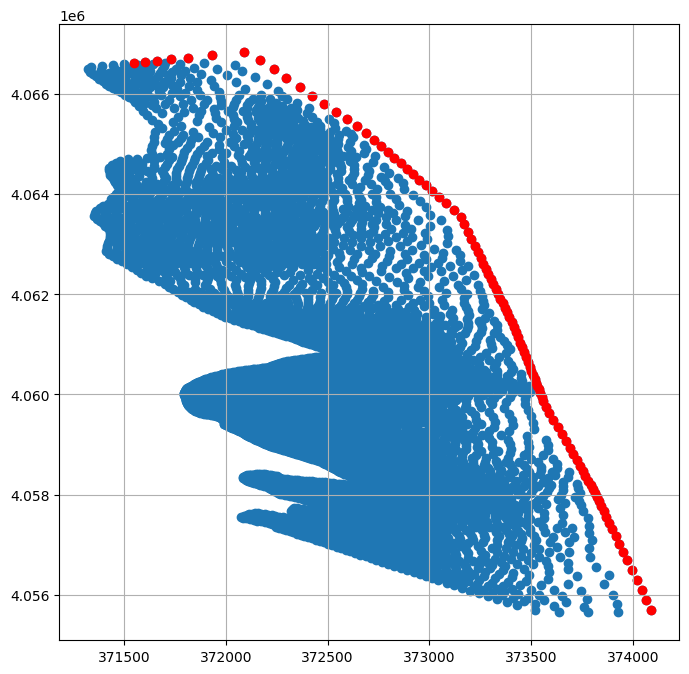

In [35]:
slf = ppSELAFIN(archS)
slf.readHeader()
NELEM, NPOIN, NDP, IKLE, IPOBO, x, y = slf.getMesh()

plt.figure(figsize=(8, 8))
plt.scatter(x,y)
plt.scatter(test[:,0],test[:,1], color="red")
plt.grid()

# Extrae los Datos del archivo SLF

Ahora generamos la serie de tiempo con siderando que tenemos la coordenada.

In [36]:
tiempo, res = extrae_TimeSeries(archR,coord,vari)

i= 0 la variable es:  VELOCITY U
i= 1 la variable es:  VELOCITY V
i= 2 la variable es:  FREE SURFACE


define la fecha
FECHA_INI es la fecha en la que quiero que inicie el postproceso.
FECHA_INI2 es la fecha en la que inicia el selafin

In [37]:
if UsaFechaSlf:
    print("Fecha de inicio a partir del archivo")
    fechita = extrae_Fecha(archR)
    FECHA_INI = str(fechita[0]) + '-' + str(fechita[1]) + '-' + str(fechita[2]) + " " + str(fechita[3]) + ":" + str(fechita[4]) + ":" +str(fechita[5])
    reprocesa = False
    FECHA_INI2 = FECHA_INI
    print("La fecha inicial es:", FECHA_INI)
else:
    print("Fecha de inicio definida por el usuario")
    fechita = fecha
    reprocesa = True
    FECHA_INI = fechita  + " 00:00:00"
    print("La fecha inicial es:", FECHA_INI)

Fecha de inicio a partir del archivo
La fecha inicial es: 2023-8-10 0:0:0


# Considera la fecha y extrae en el rango

In [38]:
if reprocesa:
    ### crea un dataframe con las fechas #####
    # Convertir la fecha inicial a un objeto datetime
    #fecha del archivo selafin
    fArc = extrae_Fecha(archR)
    FECHA_INI2 = str(fArc[0]) + '-' + str(fArc[1]) + '-' + str(fArc[2]) + " " + str(fArc[3]) + ":" + str(fArc[4]) + ":" +str(fArc[5])
    fecha_ini_dt = pd.to_datetime(FECHA_INI2)
    # Sumar el tiempo en segundos a la fecha inicial
    fechas = [fecha_ini_dt + pd.Timedelta(seconds=int(t)) for t in tiempo]
    ### determina la fila en donde inicia la fecha impuesta
    df =pd.DataFrame(fechas)
    orden = df.loc[df[0] >= FECHA_INI].index[0]
    ### reescribe las variable res y tiempo
    tiempo = np.array(tiempo)
    tiempo1 = tiempo[orden:]-tiempo[orden]
    res1 = res[:,orden:,:]
else:
    res1 = res
    tiempo1 = np.array(tiempo)

# Salva como archivo(s) de texto

In [85]:
res1.shape

(100, 11522, 3)

In [39]:
Nborde = Nlocal.reshape((1,len(Nlocal)))
Nborde = Nborde.astype(int)
Tamano = len(coord)
# Abre un archivo de texto para escritura
with open("borde.txt", "w") as f:

    # Escribe el tamaño del arreglo en la primera línea
    f.write(str(Tamano) + "\n")

    # Escribe la lista de elementos del arreglo en la siguiente línea
    for elemento in Nborde[0]:
        f.write(str(elemento) + " ")

# Cierra el archivo de texto
f.close()

In [40]:
Nborde

array([[  5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
         18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
         31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
         83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
         96,  97,  98,  99, 100, 101, 102, 103, 104]])

In [41]:
output_file = os.path.join(rutabase,salida)
#write_files(output_file,res,vari)
write_only_one_file_with_time(output_file, res1, vari, tiempo1)
#write_files_with_time(output_file, res1, vari, tiempo1)
print(f"La ruta de archivo es: {output_file}")
print(f"La fecha del archivo a considerar como inicio es: {FECHA_INI}")

(11522, 301)
done!
La ruta de archivo es: /home/model2/Desktop/Telemac_varios/maga/carrera/tides/base/bordeC.csv
La fecha del archivo a considerar como inicio es: 2023-8-10 0:0:0


In [42]:
pwd

'/home/model2'

# Harmonicos

importamos la librería

In [43]:
#!pip install utide
import utide
print(utide.__version__)

/home/model2/ambientes/ML2/lib/python3.10/site-packages/utide/harmonics.py:16: RuntimeWarning: invalid value encountered in cast
  nshallow = np.ma.masked_invalid(const.nshallow).astype(int)
/home/model2/ambientes/ML2/lib/python3.10/site-packages/utide/harmonics.py:17: RuntimeWarning: invalid value encountered in cast
  ishallow = np.ma.masked_invalid(const.ishallow).astype(int) - 1


0.3.0


## Funciones para los Harmónicos

In [44]:
res = res1
tiempo = tiempo1

In [45]:
def Estima_armonico_sup(DF, Lat, const_default=None):
  """ Se recibe el DataFrame (DF)
  que tiene lo siguiente:
  "Time":  Fecha con hora (Datetime) además esto debe ser el indice
  "Surface" Superficie libre de telemac
  """
  if const_default == None:
        const_default= ['M2', 'K1', 'O1', 'N2', 'S2', 'MSF', 'MU2', 'NO1', 'MM', 'Q1',
               'M6', '2MS6', '2MN6', 'L2', 'ALP1', 'M4', 'OO1', 'SK3', 'MS4',
               'EPS2', '2MK5', 'MN4', 'J1', '2SM6', 'UPS1', 'S4']
        
   
  DF["anomaly"] =DF["Surface"] - DF["Surface"].mean()


  coef = utide.solve(
    DF.index,
    DF["anomaly"],
    lat=Lat,
    constit = const_default,
    method="ols",
    #conf_int="MC",
    trend=False, 
    Rayleigh_min=0.95, 
    #conf_int=True,
    verbose=False,)
  return coef

def plot_ts(coef_base,coef_res, fechaINI = "2022-01-01", dt="10 min", 
            N_dt=60/10*24*30, titulo = "titulo"):
  t =  pd.date_range(start=fechaINI, periods=N_dt, freq=dt)
  # Crear DataFrame con la serie de tiempo como índice
  #df = pd.DataFrame(t, columns=['fecha'])
  base = utide.reconstruct(t, coef_base, verbose=False)
  res = utide.reconstruct(t, coef_res, verbose=False)
  fig, (ax0,ax1) =plt.subplots(figsize=(17, 8), nrows=2, sharey=True, 
                                    sharex=True,)
  base = base.h - np.mean(base.h)
  res = res.h- np.mean(res.h)
  ax0.plot(t, base, label="Observaciones", color="C0")
  ax0.plot(t, res, label = "Predicciones", color="C1")
  ax0.legend()
  ax1.plot(t, base - res, label="diferencias", color="C2")
  fig.suptitle(titulo)


  return plt.plot()

def ap2ep(Au, PHIu, Av, PHIv, plot_demo=False):
    """
    Convert tidal amplitude and phase lag (ap-) parameters into tidal ellipse
    (ep-) parameters. Please refer to ep2ap for its inverse function.

    Usage:

    SEMA, ECC, INC, PHA, w = ap2ep(Au, PHIu, Av, PHIv, plot_demo=False)

    Where:

        Au, PHIu, Av, PHIv are the amplitudes and phase lags (in degrees) of
        u- and v- tidal current components. They can be vectors or
        matrices or multidimensional arrays.

        plot_demo is an optional argument, when it is supplied as an array
        of indices, say [i j k l], the program will plot an ellipse
        corresponding to Au[i, j, k, l], PHIu[i, j, k, l], Av[i, j, k, l], and
        PHIv[i, j, k, l]. Defaults to False (i.e. no plot).

        Any number of dimensions are allowed as long as your computer
        resource can handle.

        SEMA: Semi-major axes, or the maximum speed.

        ECC:  Eccentricity, the ratio of semi-minor axis over the semi-major
              axis; its negative value indicates that the ellipse is traversed
              in clockwise direction.

        INC:  Inclination, the angles (in degrees) between the semi-major axes
              and u-axis.

        PHA:  Phase angles, the time (in angles and in degrees) when the tidal
              currents reach their maximum speeds,  (i.e.  PHA=omega*tmax).

              These four ep-parameters will have the same dimensionality (i.e.,
              vectors, or matrices) as the input ap-parameters.

        w:    A matrix whose rows allow for plotting ellipses and whose columns
              are for different ellipses corresponding columnwise to SEMA. For
              example, plot(np.real(w[0, :]), np.imag(w[0, :])) will let you
              see the first ellipse. You may need to use squeeze function when
              w is a more than two dimensional array. See example.py.

    Document:   tidal_ellipse.ps

    Revisions: May  2002, by Zhigang Xu,  --- adopting Foreman's northern semi
    major axis convention.

    For a given ellipse, its semi-major axis is undetermined by 180. If we
    borrow Foreman's terminology to call a semi major axis whose direction lies
    in a range of [0, 180) as the northern semi-major axis and otherwise as a
    southern semi major axis, one has freedom to pick up either northern or
    southern one as the semi major axis without affecting anything else.
    Foreman (1977) resolves the ambiguity by always taking the northern one as
    the semi-major axis. This revision is made to adopt Foreman's convention.
    Note the definition of the phase, PHA, is still defined as the angle
    between the initial current vector, but when converted into the maximum
    current time, it may not give the time when the maximum current first
    happens; it may give the second time that the current reaches the maximum
    (obviously, the 1st and 2nd maximum current times are half tidal period
    apart) depending on where the initial current vector happen to be and its
    rotating sense.

    Version 2, May 2002

    Converted to Python by Pierre Cazenave, October 2012.

    Authorship Copyright:

       The author retains the copyright of this program, while  you are welcome
    to use and distribute it as long as you credit the author properly and
    respect the program name itself. Particularly, you are expected to retain
    the original author's name in this original version or any of its modified
    version that you might make. You are also expected not to essentially
    change the name of the programs except for adding possible extension for
    your own version you might create, e.g. ap2ep_xx is acceptable.  Any
    suggestions are welcome and enjoy my program(s)!


    Author Info:
    _______________________________________________________________________
      Zhigang Xu, Ph.D.
      (pronounced as Tsi Gahng Hsu)
      Research Scientist
      Coastal Circulation
      Bedford Institute of Oceanography
      1 Challenge Dr.
      P.O. Box 1006                    Phone  (902) 426-2307 (o)
      Dartmouth, Nova Scotia           Fax    (902) 426-7827
      CANADA B2Y 4A2                   email xuz@dfo-mpo.gc.ca
    _______________________________________________________________________

    Release Date: Nov. 2000, Revised on May. 2002 to adopt Foreman's northern
    semi major axis convention.

    """

    # Assume the input phase lags are in degrees and convert them in radians.
    PHIu = PHIu / 180 * np.pi
    PHIv = PHIv / 180 * np.pi

    # Make complex amplitudes for u and v
    i = 1j
    u = Au * np.exp(-i * PHIu)
    v = Av * np.exp(-i * PHIv)

    # Calculate complex radius of anticlockwise and clockwise circles:
    wp = (u + i * v) / 2           # for anticlockwise circles
    wm = np.conj(u - i * v) / 2    # for clockwise circles
    # and their amplitudes and angles
    Wp = np.abs(wp)
    Wm = np.abs(wm)
    THETAp = np.angle(wp)
    THETAm = np.angle(wm)

    # calculate ep-parameters (ellipse parameters)
    SEMA = Wp + Wm                 # Semi Major Axis, or maximum speed
    SEMI = Wp - Wm                 # Semi Minor Axis, or minimum speed
    ECC = SEMI / SEMA              # Eccentricity

    PHA = (THETAm - THETAp) / 2    # Phase angle, the time (in angle) when
                                   # the velocity reaches the maximum
    INC = (THETAm + THETAp) / 2    # Inclination, the angle between the
                                   # semi major axis and x-axis (or u-axis).

    # convert to degrees for output
    PHA = PHA / np.pi*180
    INC = INC / np.pi*180
    THETAp = THETAp / np.pi*180
    THETAm = THETAm / np.pi*180

    # map the resultant angles to the range of [0, 360].
    PHA = np.mod(PHA + 360, 360)
    INC = np.mod(INC + 360, 360)

    # Mar. 2, 2002 Revision by Zhigang Xu    (REVISION_1)
    # Change the southern major axes to northern major axes to conform the tidal
    # analysis convention  (cf. Foreman, 1977, p. 13, Manual For Tidal Currents
    # Analysis Prediction, available in www.ios.bc.ca/ios/osap/people/foreman.htm)
    k = np.fix(INC / 180)
    INC = INC - k * 180
    PHA = PHA + k * 180
    PHA = np.mod(PHA, 360)

    if plot_demo:
        plot_ell(SEMA, ECC, INC, PHA, plot_demo)

    ndot = np.prod(np.shape(SEMA))
    dot = 2 * np.pi / ndot
    ot = np.arange(0, 2 * np.pi, dot)
    w = wp.flatten() * np.exp(i * ot) + wm.flatten() * np.exp(-i * ot)
    w = np.reshape(w, np.shape(wp))

    return SEMA, ECC, INC, PHA, w


def ep2ap(SEMA, ECC, INC, PHA, plot_demo=False):
    """
    Convert tidal ellipse parameters into amplitude and phase lag parameters.
    Its inverse is app2ep.m. Please refer to app2ep for the meaning of the
    inputs and outputs.

    Zhigang Xu
    Oct. 20, 2000

    Converted to Python by Pierre Cazenave, October 2012.

    Authorship Copyright:

        The author of this program retains the copyright of this program, while
    you are welcome to use and distribute this program as long as you credit
    the author properly and respect the program name itself. Particularly, you
    are expected to retain the original author's name in this original version
    of the program or any of its modified version that you might make.  You are
    also expected not to essentially change the name of the programs except for
    adding possible extension for your own version you might create, e.g.
    app2ep_xx is acceptable.  Any suggestions are welcome and enjoy my
    program(s)!


    Author Info:
    _______________________________________________________________________
      Zhigang Xu, Ph.D.
      (pronounced as Tsi Gahng Hsu)
      Research Scientist
      Coastal Circulation
      Bedford Institute of Oceanography
      1 Challenge Dr.
      P.O. Box 1006                    Phone  (902) 426-2307 (o)
      Dartmouth, Nova Scotia           Fax    (902) 426-7827
      CANADA B2Y 4A2                   email xuz@dfo-mpo.gc.ca
    _______________________________________________________________________

    Release Date: Nov. 2000

    """

    i = 1j

    Wp = (1 + ECC) / 2 * SEMA
    Wm = (1 - ECC) / 2 * SEMA
    THETAp = INC - PHA
    THETAm = INC + PHA

    # Convert degrees into radians
    THETAp = THETAp / 180 * np.pi
    THETAm = THETAm / 180 * np.pi

    # Calculate wp and wm.
    wp = Wp * np.exp(i * THETAp)
    wm = Wm * np.exp(i * THETAm)

    ndot = np.prod(np.shape(SEMA))
    dot = 2 * np.pi / ndot
    ot = np.arange(0, 2 * np.pi, dot)
    w = wp.flatten() * np.exp(i * ot) + wm.flatten() * np.exp(-i * ot)
    w = np.reshape(w, np.shape(wp))

    # Calculate cAu, cAv --- complex amplitude of u and v
    cAu = wp + np.conj(wm)
    cAv = -i * (wp-np.conj(wm))
    Au = np.abs(cAu)
    Av = np.abs(cAv)
    PHIu = -np.angle(cAu) * 180 / np.pi
    PHIv = -np.angle(cAv) * 180 / np.pi

    # flip angles in the range of [-180 0) to the range of [180 360).
    id = PHIu < 0
    PHIu[id] = PHIu[id] + 360
    id = PHIv < 0
    PHIv[id] = PHIv[id] + 360

    if plot_demo:
        plot_ell(SEMA, ECC, INC, PHA, plot_demo)

    return Au, PHIu, Av, PHIv, w

def sub2ind(shape, pos):
    """
    Substitute of MATLAB's sub2ind function for NumPy.

    t = numpy.random.random([2, 4, 5, 2])
    n = sub2ind(numpy.shape(t), [1, 2, 4, 1])
    >>> n
    69

    From http://stackoverflow.com/questions/4114461

    """
    res = 0
    acc = 1
    for pi, si in zip(reversed(pos), reversed(shape)):
        res += pi * acc
        acc *= si

    return res


def plot_ell(SEMA, ECC, INC, PHA, IND=[1]):
    """
    An auxiliary function used in ap2ep and ep2ap for plotting tidal ellipse.
    The inputs, MA, ECC, INC and PHA are the output of ap2ep and IND is a
    vector for indices for plotting a particular ellipse, e.g., if IND=[2 3 1]
    the ellipse corresponding to the indices of [2, 3, 1] will be plotted.

    By default, the first ellipse is always plotted.

    Converted to Python by Pierre Cazenave, October 2012.

    """

    len_IND = len(IND)
    if IND:
        cmd = 'sub2ind(size_SEMA, '
        if len_IND == 1:
            titletxt = 'Ellipse '
        else:
            titletxt = 'Ellipse ('

        for k in range(len_IND):
            if k == 0:
                cmd = cmd + '[' + str(IND[k])
            else:
                cmd = cmd + ',' + str(IND[k])

            if k < len_IND-1:
                titletxt = titletxt + str(IND[k]) + ','
            elif len_IND == 1:
                titletxt = titletxt + str(IND[k])
            else:
                titletxt = titletxt + str(IND[k]) + ')'

        cmd = 'n = ' + cmd + '])'
        # This is pretty nasty, but it works.
        exec(cmd)

        plt.gcf()
        plt.clf()
        do_the_plot(SEMA.flatten()[n], ECC.flatten()[n], INC.flatten()[n], PHA.flatten()[n])
        titletxt = titletxt + ',  (red) green (anti-) clockwise component'
        plt.title(titletxt)
    elif len_IND:
        print('IND input contains zero element(s)!\nNo ellipse will be plotted.')


def do_the_plot(SEMA, ECC, INC, PHA):
    """
    Ellipse plot subfunction.

    Converted to Python by Pierre Cazenave, October 2012.

    """

    i = 1j

    SEMI = SEMA * ECC
    Wp = (1 + ECC) / 2 * SEMA
    Wm = (1 - ECC) / 2 * SEMA
    THETAp = INC - PHA
    THETAm = INC + PHA

    # Convert degrees into radians
    THETAp = THETAp / 180 * np.pi
    THETAm = THETAm / 180 * np.pi
    INC = INC / 180 * np.pi
    PHA = PHA / 180 * np.pi

    # Calculate wp and wm.
    wp = Wp * np.exp(i * THETAp)
    wm = Wm * np.exp(i * THETAm)

    dot = np.pi / 36
    ot = np.arange(0, 2 * np.pi, dot)
    a = wp * np.exp(i * ot)
    b = wm * np.exp(-i * ot)
    w = a + b

    wmax = SEMA * np.exp(i * INC)
    wmin = SEMI * np.exp(i * (INC + np.pi / 2))

    plt.plot(np.real(w), np.imag(w))
    plt.axis('equal')
    plt.hold('on')
    plt.plot([0, np.real(wmax)], [0, np.imag(wmax)], 'm')
    plt.plot([0, np.real(wmin)], [0, np.imag(wmin)], 'm')
    plt.xlabel('u')
    plt.ylabel('v')
    plt.plot(np.real(a), np.imag(a), 'r')
    plt.plot(np.real(b), np.imag(b), 'g')
    plt.plot([0, np.real(a[0])], [0, np.imag(a[0])], 'ro')
    plt.plot([0, np.real(b[0])], [0, np.imag(b[0])], 'go')
    plt.plot([0, np.real(w[0])], [0, np.imag(w[0])], 'bo')
    plt.plot(np.real(a[0]), np.imag(a[0]), 'ro')
    plt.plot(np.real(b[0]), np.imag(b[0]), 'go')
    plt.plot(np.real(w[0]), np.imag(w[0]), 'bo')
    plt.plot(np.real([a[0], a[0]+b[0]]), np.imag([a[0], a[0]+b[0]]), linestyle='--', color='g')
    plt.plot(np.real([b[0], a[0]+b[0]]), np.imag([b[0], a[0]+b[0]]), linestyle='--', color='r')

    for n in range(len(ot)):
        plt.hold('on')
        plt.plot(np.real(a[n]), np.imag(a[n]), 'ro')
        plt.plot(np.real(b[n]), np.imag(b[n]), 'go')
        plt.plot(np.real(w[n]), np.imag(w[n]), 'bo')

    plt.hold('off')
    plt.show()


def prep_plot(SEMA, ECC, INC, PHA):
    """
    Take the output of ap2ep (SEMA, ECC, INC, and PHA) and prepare it for
    plotting.

    This is extracted from do_the_plot above, but allows quicker access when
    all that is required is a plot of an ellipse, for which only w is really
    required.

    Returns w, wmin and wmax (w is used for plotting the ellipse, see
    plot_ell).

    """

    i = 1j

    SEMI = SEMA * ECC
    Wp = (1 + ECC) / 2 * SEMA
    Wm = (1 - ECC) / 2 * SEMA
    THETAp = INC - PHA
    THETAm = INC + PHA

    # Convert degrees into radians
    THETAp = THETAp / 180 * np.pi
    THETAm = THETAm / 180 * np.pi
    INC = INC / 180 * np.pi
    PHA = PHA / 180 * np.pi

    # Calculate wp and wm.
    wp = Wp * np.exp(i * THETAp)
    wm = Wm * np.exp(i * THETAm)

    dot = np.pi / 36
    ot = np.arange(0, 2 * np.pi, dot)
    a = wp * np.exp(i * ot)
    b = wm * np.exp(-i * ot)
    w = a + b

    # Repeat the first position in w so we close the ellipse.
    w = np.hstack((w, w[0]))

    wmax = SEMA * np.exp(i * INC)
    wmin = SEMI * np.exp(i * (INC + np.pi / 2))

    return w, wmin, wmax



Más facil pasar todo a DataFrame.
El DataFrame tiene que tener Fecha y Hora, esta la extraemos del archivo de Resultado del TELEMAC (UTC=0)

creo el DataFrame

In [46]:
# Convertir la fecha inicial a un objeto datetime
fecha_ini_dt = pd.to_datetime(FECHA_INI)
# Sumar el tiempo en segundos a la fecha inicial
fechas = [fecha_ini_dt + pd.Timedelta(seconds=int(t)) for t in tiempo]
# Crear un DataFrame con ese índice
dfT = pd.DataFrame(index=fechas)

Agrego ahora el dato, y dejo el tiempo como indice.

## Calculo los Harmonicos: Ejemplo 
Un simple ejemplo

In [47]:
tiempo

array([      0.,  864000.,  864600., ..., 7774800., 7775400., 7776000.])

In [48]:
df = pd.DataFrame()
df.index = dfT.index
df["Surface"] = res[1,:,2]
Latx = lat[1]

In [49]:
resultadoH = Estima_armonico_sup(df, Latx, const_default=None)

El resultado contiene los coeficientes de los armonicos, estimados. 

Las frecuencias de los armónicos usados es:

In [50]:
freq = resultadoH["aux"]["frq"]

La amplitud se puede extraer de la misma manera:

In [51]:
amplitud = resultadoH["A"]

Y el desfase.

In [52]:
desfase = resultadoH['g']

y el nombre de los respectivos harmónicos

In [53]:
nombres = resultadoH["name"]

In [54]:
# APlicamos un Loop para Todos los puntos. 

In [55]:
seleccion = ['M2','K1','S2','O1','N2','M6']

In [56]:
resultadoH2 = Estima_armonico_sup(df, Latx, const_default=seleccion)

In [57]:
amplitud2 = resultadoH2["A"]

In [58]:
amplitud2

array([0.49807148, 0.25926615, 0.2466026 , 0.20701042, 0.06542108,
       0.06092463])

# ejemplo ficticio para u,v
Notar que el resultado es una elipse con el eje mayor, la excentricidad, el angulo de la elipse y la fase.

In [59]:
def fake_tide(t, M2amp, M2phase):
    """
    Generate a minimally realistic-looking fake semidiurnal tide.
    
    t is time in hours
    phases are in radians
    
    Modified from: http://currents.soest.hawaii.edu/ocn760_4/_static/plotting.html
    """
    return M2amp * np.sin(2 * np.pi * t / 12.42 - M2phase)

In [60]:
from pandas import date_range
N = 500

t = date_range(start="2016-03-29", periods=N, freq="H")

# Signal + some noise.
u = fake_tide(np.arange(N), M2amp=2, M2phase=0) + np.random.randn(N)*0.2
v = fake_tide(np.arange(N), M2amp=1, M2phase=np.pi) + np.random.randn(N)*0.2

/tmp/ipykernel_4035368/241903217.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t = date_range(start="2016-03-29", periods=N, freq="H")


In [61]:

coef = utide.solve(
    t, u, v,
    lat=-42.5,
    nodal=False,
    trend=False,
    method='ols',
    conf_int='linear',
    Rayleigh_min=0.95,
)

solve: matrix prep ... solution ... done.


In [62]:
SEMA = coef['Lsmaj']
ECC  = coef["Lsmin"]
INC  = coef["theta"]
PHA  = coef["g"]

usamos las funciones para pasar a 1D, estos valores podemos hacerlo para hacer una reconstrucción manual. La idea acá es pasar del formato elipse 2D a Armónicos simples (1D)

In [63]:
 Au, PHIu, Av, PHIv, w = ep2ap(SEMA, ECC, INC, PHA, plot_demo=False)

Tambien podemos usar las funciones predefinidas de Utide para reconstruir

In [64]:
from utide import reconstruct
tide = reconstruct(t, coef)

prep/calcs ... done.


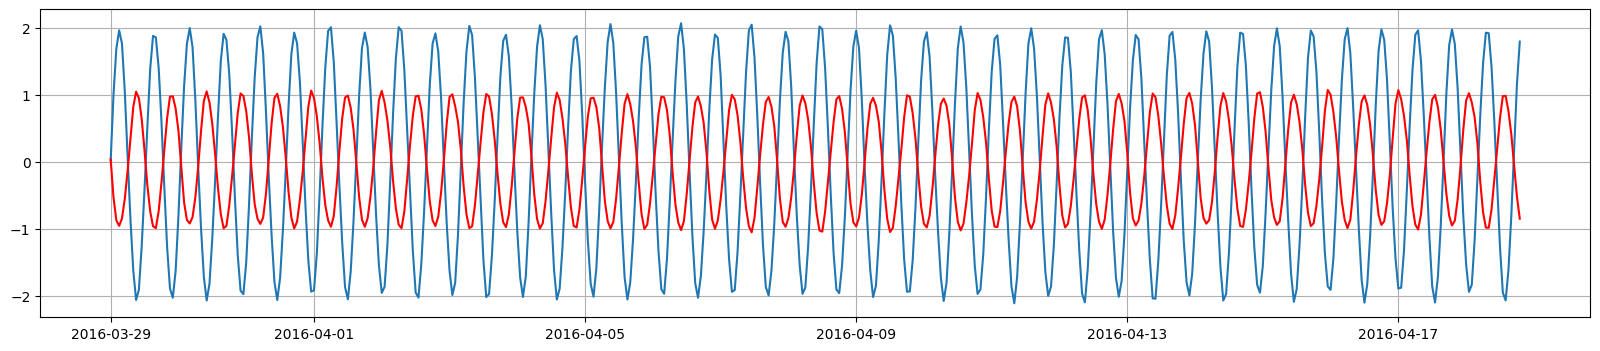

In [65]:
plt.figure(figsize=(20, 4))
plt.plot(t,tide["u"])
plt.plot(t,tide["v"], color="red")
plt.grid()

### Genero condiciones de borde considerando solo H

In [66]:
from pandas import date_range
from utide import reconstruct
def CondBorde(coef, fecha_inicial, dt, fecha_final):
    """ coef: resultado de Utide base para el uso de los constituyentes
        fecha_inicial: la fecha para la cual se crea la series de tiempo
        dt : delta tiempo en minutos de la serie
        Fecha_final : la fecha en la que termina la serie de tiempo"""   
    dt1 = str(dt) + "T" 
    print(dt1)
    fechas = pd.to_datetime([fecha_inicial, fecha_final], format="%d/%m/%Y")
    tt = date_range(start= fechas[0], end= fechas[1], freq=dt1)
    tide = reconstruct(tt, coef)
    H = tide.h
    N = len(tt)
    print(N)
    dt2 = dt*60.0
    t = np.arange(0,N*dt2,dt2)
    return t, H, tt

In [67]:
#date_range(start= '1/1/2023', end= '31/12/2025', freq='30 T')
fechas = pd.to_datetime(['1/1/2023', '31/12/2025'], format="%d/%m/%Y")
date_range(start= fechas[0], end= fechas[1], freq='30T')

/tmp/ipykernel_4035368/1945306862.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range(start= fechas[0], end= fechas[1], freq='30T')


DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 00:30:00',
               '2023-01-01 01:00:00', '2023-01-01 01:30:00',
               '2023-01-01 02:00:00', '2023-01-01 02:30:00',
               '2023-01-01 03:00:00', '2023-01-01 03:30:00',
               '2023-01-01 04:00:00', '2023-01-01 04:30:00',
               ...
               '2025-12-30 19:30:00', '2025-12-30 20:00:00',
               '2025-12-30 20:30:00', '2025-12-30 21:00:00',
               '2025-12-30 21:30:00', '2025-12-30 22:00:00',
               '2025-12-30 22:30:00', '2025-12-30 23:00:00',
               '2025-12-30 23:30:00', '2025-12-31 00:00:00'],
              dtype='datetime64[ns]', length=52561, freq='30min')

In [68]:
fechas[0]

Timestamp('2023-01-01 00:00:00')

In [69]:
ja1, ja2, tver = CondBorde(resultadoH2, '1/1/2023', 30, '31/12/2025')

30T
prep/calcs ... 

/tmp/ipykernel_4035368/1428423061.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  tt = date_range(start= fechas[0], end= fechas[1], freq=dt1)


done.
52561


In [70]:
df_exterior = pd.DataFrame({ "Tiempo": ja1,
                            "SL":ja2 })

In [71]:
df_exterior.to_csv("alturas.csv")

In [72]:
3600/2.5

1440.0

# Aplicamos el loop a todos los puntos del SELAFIN

En este caso hago el loop con las coordenadas en lat lon (del archivo original)

## Para cada punto creo un dataFrame considerando la fecha y el tiempo del dato extraido


Archivo de texto.

## Estimamos los harmónicos para H

In [73]:
fecha_ini_dt = pd.to_datetime(FECHA_INI)
fechas = [fecha_ini_dt + pd.Timedelta(seconds=int(t)) for t in tiempo]
dfT = pd.DataFrame(index=fechas)
AmpHarmonicos = pd.DataFrame(columns= const_default)
PhaseHarmonicos = pd.DataFrame(columns= const_default)
NodosID = idNodos(archC,H=5,U=6,V=6)

for i,cord in enumerate(coord):
    df = pd.DataFrame()
    df.index = dfT.index
    df["Surface"] = res[i,:,2]
    latx = coord[i,1]
    resultadoH = Estima_armonico_sup(df, Latx, const_default)
    AmpHarmonicos.loc[i] = resultadoH.A
    PhaseHarmonicos.loc[i] = resultadoH.g
    
        
    
    

In [74]:
FreqHarmonicos = pd.DataFrame(columns = const_default)
FreqHarmonicos.loc[0] = resultadoH.aux["frq"]

In [75]:
AmpHarmonicos.index = NodosID
PhaseHarmonicos.index = NodosID

## Estimamos los harmónicos para U y V

In [76]:
UAmpHarmonicos = pd.DataFrame(columns= const_default)
UPhaseHarmonicos = pd.DataFrame(columns= const_default)
VAmpHarmonicos = pd.DataFrame(columns= const_default)
VPhaseHarmonicos = pd.DataFrame(columns= const_default)


for i,c in enumerate(coord):
    df = pd.DataFrame()
    df.index = dfT.index
    df["U"] = res[i,:,0]
    df["V"] = res[i,:,1]
    latx = coord[i,1]
    coef = utide.solve( df.index,df["U"],df["V"],
                       lat=latx,
                       constit = const_default,
                       method="ols",
                       #conf_int="MC",
                       trend=False,
                       nodal=False,
                       Rayleigh_min=0.95,
                       #conf_int=True,
                       verbose=False,)
    SEMA = coef['Lsmaj']
    ECC  = coef["Lsmin"]
    INC  = coef["theta"]
    PHA  = coef["g"]
    Au, PHIu, Av, PHIv, w = ep2ap(SEMA, ECC, INC, PHA, plot_demo=False)
    UAmpHarmonicos.loc[i] = Au
    UPhaseHarmonicos.loc[i] = PHIu
    VAmpHarmonicos.loc[i] = Av
    VPhaseHarmonicos.loc[i] = PHIv
    
    
    
    

In [77]:
# Varius Plots

In [78]:
ID = 5
dias = 15
dt = 0.02 #horas
NN = int(24/dt*dias)
SL = []
tt = []
Amp  = AmpHarmonicos.iloc[ID].to_numpy()
phase = 2*np.pi/360.0 + PhaseHarmonicos.iloc[ID].to_numpy()
Freq = FreqHarmonicos.to_numpy()
for i in range(0,NN):
    t = i*dt
    tt.append(t)
    ang = 2*np.pi *t * Freq
    #print(ang)
    SL.append( np.sum(+Amp/2*np.sin(phase)+Amp/2*np.cos(ang)))
SL = np.array(SL)
tt = np.array(tt)
fechasa = [fecha_ini_dt + pd.Timedelta(hours=float(t)) for t in tt]
dfT = pd.DataFrame(index=fechasa)
SalidaHarm = pd.DataFrame()
SalidaHarm.index = dfT.index
SalidaHarm["Surface"] = SL

In [79]:
Datos = pd.DataFrame()
tt = tiempo[tiempo <= dias*24*3600]
print(tt.shape)
fechasa = [fecha_ini_dt + pd.Timedelta(seconds=float(t)) for t in tt]
dfT = pd.DataFrame(index=fechasa)
Ndato = len(dfT)
med = res[ID,:Ndato,2] - np.average(res[ID,:,2])
Datos.index =dfT.index
Datos["Surface"] = med

(722,)


In [80]:
df = pd.DataFrame()
fechas = [fecha_ini_dt + pd.Timedelta(seconds=int(t)) for t in tiempo]
dfT = pd.DataFrame(index=fechas)
df.index = dfT.index
df["Surface"] = res[ID,:,2]
latx = coord[ID,1]
resultadoHT = Estima_armonico_sup(df, Latx, const_default)

In [81]:
tide = reconstruct(Datos.index, resultadoHT)

prep/calcs ... done.


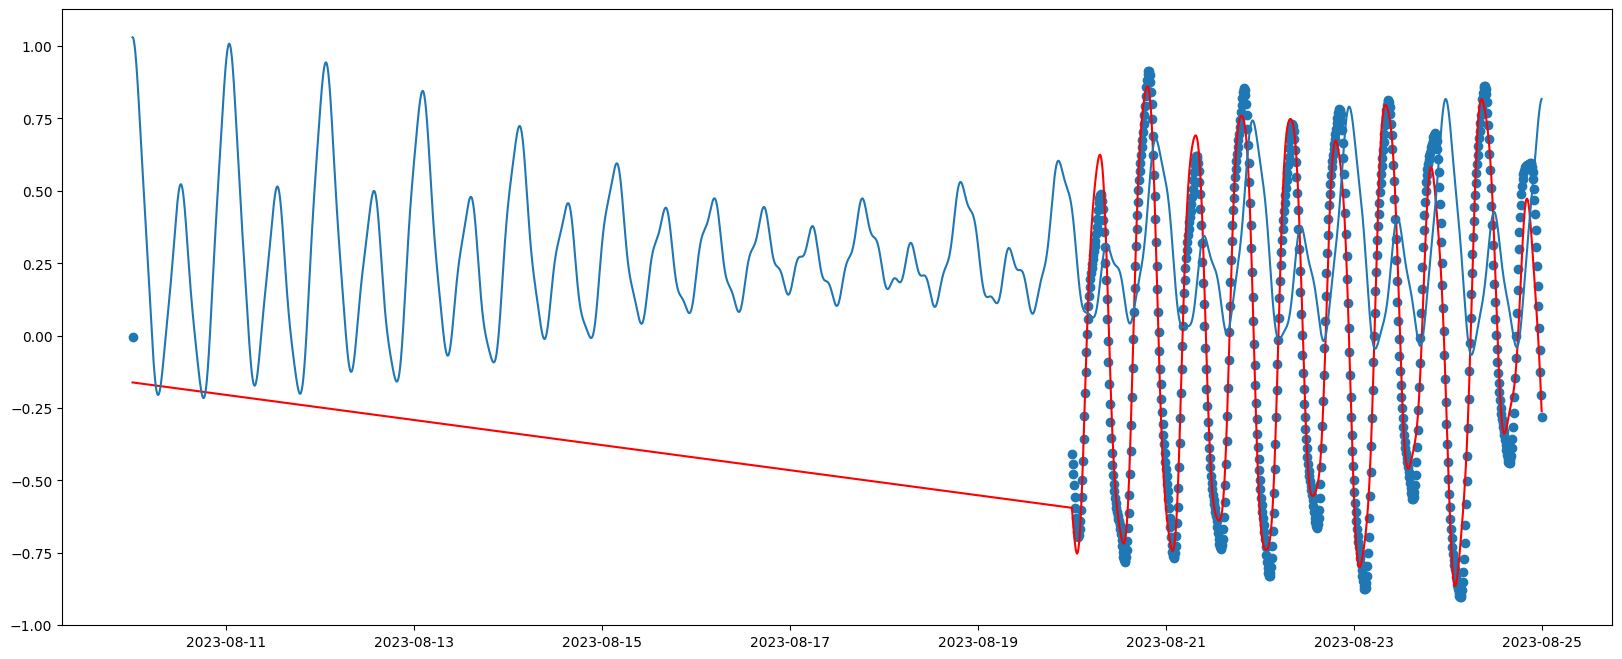

In [82]:
plt.figure(figsize=(20, 8))
plt.scatter(Datos.index,Datos["Surface"],label="Datos")
plt.plot(tide.t_in,tide.h,color="red",label="generado Ttide")
plt.plot(SalidaHarm.index,SalidaHarm["Surface"])

In [83]:
tide

{'t_in': DatetimeIndex(['2023-08-10 00:00:00', '2023-08-20 00:00:00',
                '2023-08-20 00:10:00', '2023-08-20 00:20:00',
                '2023-08-20 00:30:00', '2023-08-20 00:40:00',
                '2023-08-20 00:50:00', '2023-08-20 01:00:00',
                '2023-08-20 01:10:00', '2023-08-20 01:20:00',
                ...
                '2023-08-24 22:30:00', '2023-08-24 22:40:00',
                '2023-08-24 22:50:00', '2023-08-24 23:00:00',
                '2023-08-24 23:10:00', '2023-08-24 23:20:00',
                '2023-08-24 23:30:00', '2023-08-24 23:40:00',
                '2023-08-24 23:50:00', '2023-08-25 00:00:00'],
               dtype='datetime64[ns]', length=722, freq=None),
 'epoch': None,
 'constit': None,
 'min_SNR': 2,
 'min_PE': 0,
 't_mpl': array([738742.        , 738752.        , 738752.00694444, 738752.01388889,
        738752.02083333, 738752.02777778, 738752.03472222, 738752.04166667,
        738752.04861111, 738752.05555556, 738752.0625    , 73875

In [ ]:
ttt = tiempo/3600.
SLref = res[0,:,